In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv(r'D:\Machine_learning\Data_sets\creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
X = df.drop('Class',axis=1)
y = df['Class']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify= y ,test_size=0.20, random_state=42)

In [6]:
trf3 = ColumnTransformer([
    ('scale',StandardScaler(),slice(0,30))
])

In [7]:
X_train_scaled = trf3.fit_transform(X_train)
X_test_scaled = trf3.fit_transform(X_test)
X_train_scaled.shape
X_test_scaled.shape

(56962, 30)

In [8]:
X_train.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

# Starting Model EasyEnsembled

In [9]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, RocCurveDisplay,
    PrecisionRecallDisplay
)

ee = EasyEnsembleClassifier(
    n_estimators=20,        
    sampling_strategy=1.0,  
    random_state=42,
    n_jobs=-1
)

ee.fit(X_train_scaled, y_train)

probs = ee.predict_proba(X_test)[:, 1]

ROC-AUC  : 0.9767
PR-AUC   : 0.7501
              precision    recall  f1-score   support

    Negative       1.00      0.96      0.98     56864
    Positive       0.04      0.93      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.95      0.53     56962
weighted avg       1.00      0.96      0.98     56962

[[54765  2099]
 [    7    91]]


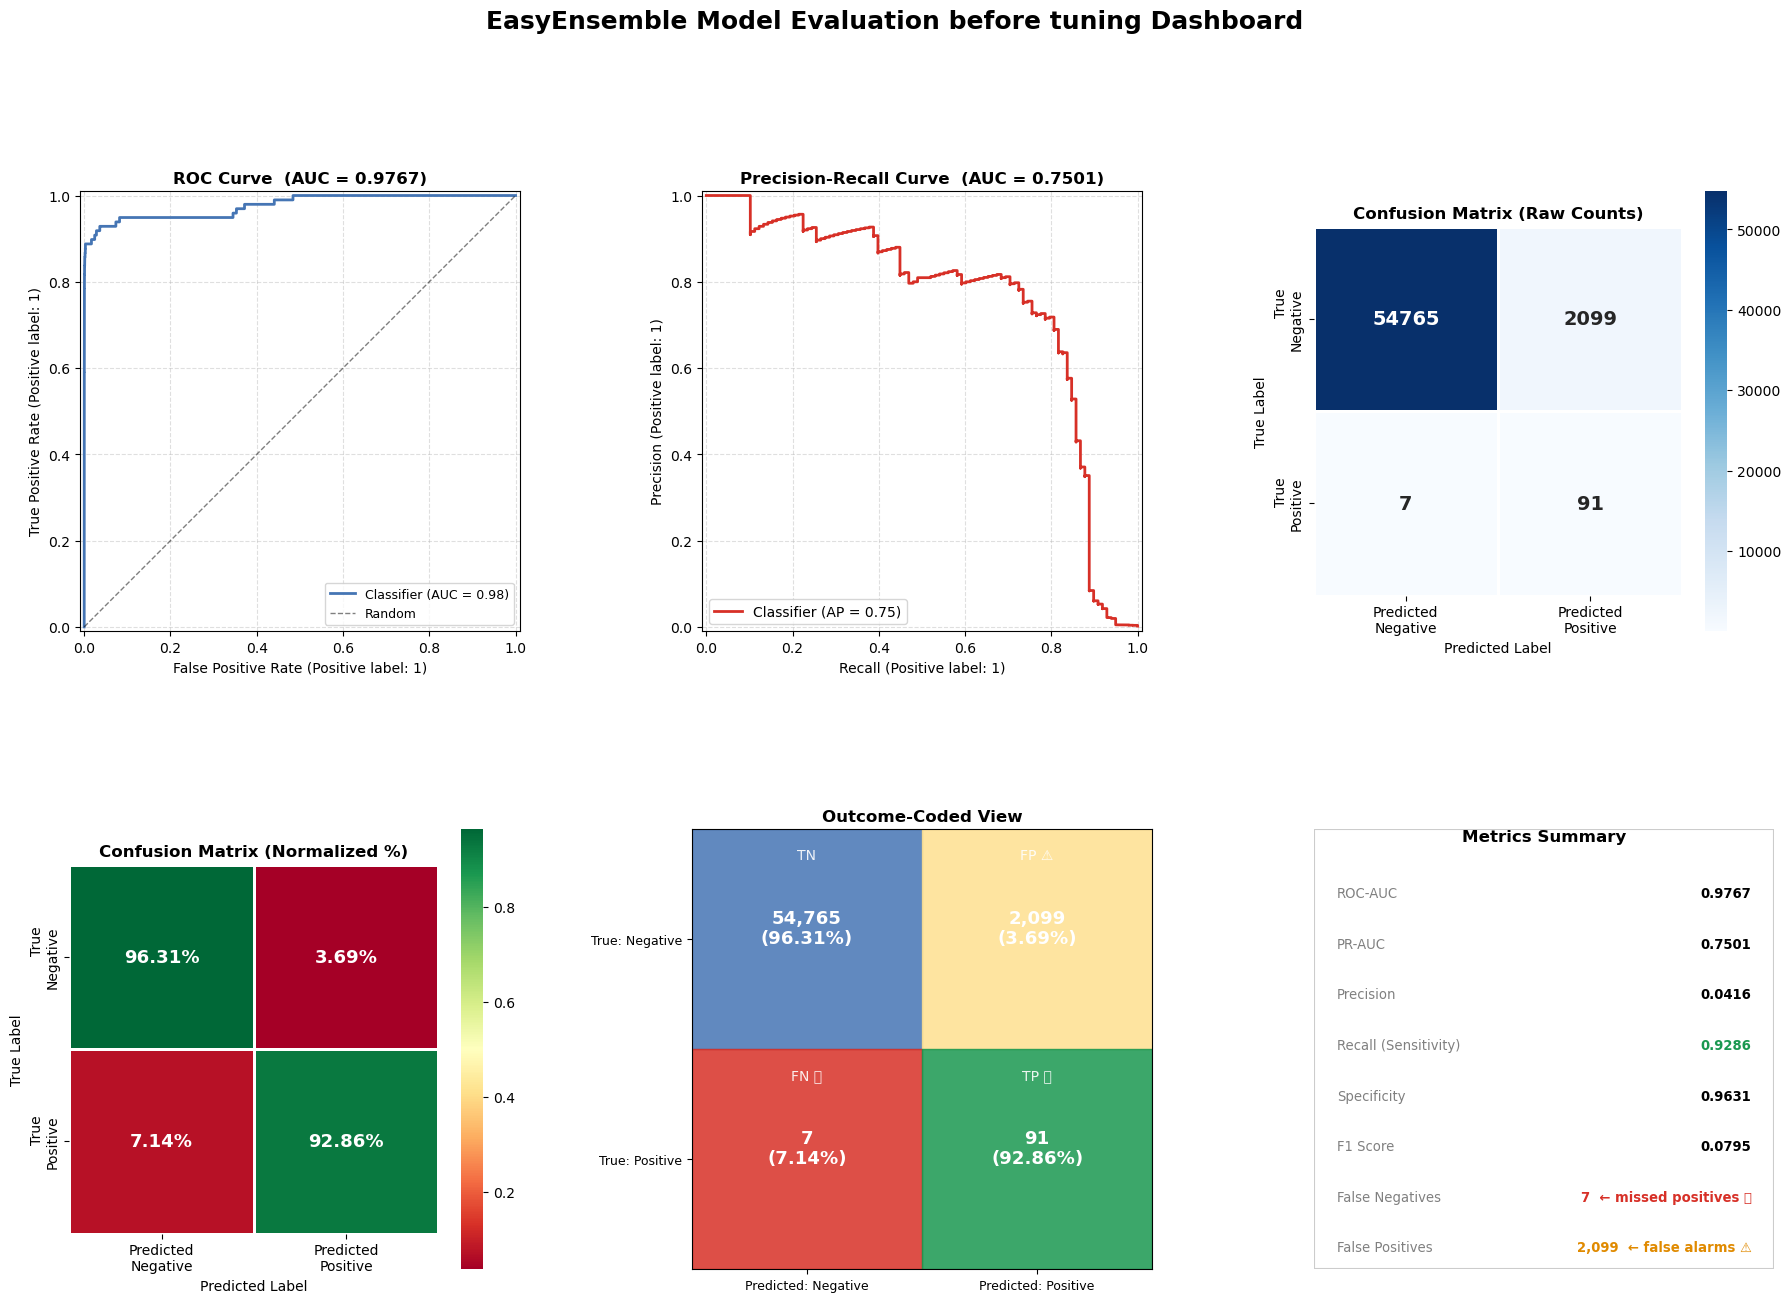

In [10]:


probs = ee.predict_proba(X_test_scaled)[:, 1]
preds = ee.predict(X_test_scaled)

# ── Core Scores ────────────────────────────────────────────────────────────────
roc_auc = roc_auc_score(y_test, probs)
pr_auc  = average_precision_score(y_test, probs)
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(classification_report(y_test, preds, target_names=["Negative", "Positive"]))

# ── Confusion Matrix Data ──────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, preds)
cm_norm = confusion_matrix(y_test, preds, normalize="true")
tn, fp, fn, tp = cm.ravel()
print(cm)

# ══════════════════════════════════════════════════════════════════════════════
# FULL EVALUATION DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 14))
fig.suptitle("EasyEnsemble Model Evaluation before tuning Dashboard", fontsize=18, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── PLOT 1 — ROC Curve ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
RocCurveDisplay.from_predictions(y_test, probs, ax=ax1, color="#4575b4", linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax1.set_title(f"ROC Curve  (AUC = {roc_auc:.4f})", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)

# ── PLOT 2 — Precision-Recall Curve ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=ax2, color="#d73027", linewidth=2)
ax2.set_title(f"Precision-Recall Curve  (AUC = {pr_auc:.4f})", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)

# ── PLOT 3 — Confusion Matrix: Raw Counts ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm, ax=ax3,
            annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Predicted\nNegative", "Predicted\nPositive"],
            yticklabels=["True\nNegative",      "True\nPositive"],
            linewidths=2, linecolor="white",
            square=True, cbar=True,
            annot_kws={"size": 14, "weight": "bold"})
ax3.set_title("Confusion Matrix (Raw Counts)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Predicted Label", fontsize=10)
ax3.set_ylabel("True Label",      fontsize=10)

# ── PLOT 4 — Confusion Matrix: Normalized ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_norm, ax=ax4,
            annot=True, fmt=".2%",
            cmap="RdYlGn",
            xticklabels=["Predicted\nNegative", "Predicted\nPositive"],
            yticklabels=["True\nNegative",      "True\nPositive"],
            linewidths=2, linecolor="white",
            square=True, cbar=True,
            annot_kws={"size": 13, "weight": "bold"})
ax4.set_title("Confusion Matrix (Normalized %)", fontsize=12, fontweight="bold")
ax4.set_xlabel("Predicted Label", fontsize=10)
ax4.set_ylabel("True Label",      fontsize=10)

# ── PLOT 5 — Outcome Color-Coded View ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
outcome_colors = [["#4575b4", "#fee090"],   # TN=blue,  FP=yellow
                  ["#d73027", "#1a9850"]]    # FN=red,   TP=green
outcome_names  = [["TN", "FP ⚠️"], ["FN 🚨", "TP ✅"]]
for i in range(2):
    for j in range(2):
        ax5.add_patch(plt.Rectangle((j, 1 - i), 1, 1,
                                     color=outcome_colors[i][j], alpha=0.85))
        ax5.text(j + 0.5, 1.55 - i,
                 f"{cm[i, j]:,}\n({cm_norm[i, j]:.2%})",
                 ha="center", va="center",
                 fontsize=13, fontweight="bold", color="white")
        ax5.text(j + 0.5, 1.88 - i, outcome_names[i][j],
                 ha="center", va="center", fontsize=10,
                 color="white", alpha=0.9)
ax5.set_xlim(0, 2); ax5.set_ylim(0, 2)
ax5.set_xticks([0.5, 1.5])
ax5.set_xticklabels(["Predicted: Negative", "Predicted: Positive"], fontsize=9)
ax5.set_yticks([0.5, 1.5])
ax5.set_yticklabels(["True: Positive", "True: Negative"], fontsize=9)
ax5.set_title("Outcome-Coded View", fontsize=12, fontweight="bold")

# ── PLOT 6 — Metrics Summary Card ────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

metrics = [
    ("ROC-AUC",          f"{roc_auc:.4f}",                   "black"),
    ("PR-AUC",           f"{pr_auc:.4f}",                    "black"),
    ("Precision",        f"{precision:.4f}",                 "black"),
    ("Recall (Sensitivity)", f"{recall:.4f}",                "#1a9850"),
    ("Specificity",      f"{specificity:.4f}",               "black"),
    ("F1 Score",         f"{f1:.4f}",                        "black"),
    ("False Negatives",  f"{fn:,}  ← missed positives 🚨",  "#d73027"),
    ("False Positives",  f"{fp:,}  ← false alarms ⚠️",      "#e08a00"),
]
ax6.text(0.5, 1.0, "Metrics Summary", ha="center",
         fontsize=12, fontweight="bold", va="top")
y = 0.87
for name, val, color in metrics:
    ax6.text(0.05, y, name,  fontsize=9.5, va="top", color="gray")
    ax6.text(0.95, y, val,   fontsize=9.5, va="top", ha="right",
             fontweight="bold", color=color)
    y -= 0.115
ax6.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                              edgecolor="#cccccc", linewidth=1.5,
                              transform=ax6.transAxes))

plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Testing Multiple Models with Hyper-Parameter tuning using Random Search


## EasyEnsembleClassifier With DecisionTreeClassifier

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 


param_dist_easy = {
    "n_estimators": [50, 100, 200],
    "estimator__max_depth": [3, 5, 10],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 5],
    "estimator__max_features": ["sqrt", "log2"]
}
model_easy = EasyEnsembleClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'))

classifier_easy = RandomizedSearchCV(estimator=(model_easy),param_distributions=param_dist_easy,n_iter=10,cv = cv ,scoring="average_precision",   n_jobs=-1, verbose=2,random_state=42)
classifier_easy.fit(X,y)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=EasyEnsembleClassifier(estimator=DecisionTreeClassifier(class_weight='balanced')),
                   n_jobs=-1,
                   param_distributions={'estimator__max_depth': [3, 5, 10],
                                        'estimator__max_features': ['sqrt',
                                                                    'log2'],
                                        'estimator__min_samples_leaf': [1, 2,
                                                                        5],
                                        'estimator__min_samples_split': [2, 5,
                                                                         10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='average_precision', verbose=2)

In [15]:
results_easy = pd.DataFrame(classifier_easy.cv_results_)
results_easy = results_easy.sort_values('mean_test_score',ascending=False).head(1)
results_easy

results_easy[['param_n_estimators','param_estimator__min_samples_split','param_estimator__min_samples_leaf','param_estimator__max_features','param_estimator__max_depth', 'mean_test_score']].sort_values('mean_test_score',ascending=False).head(1)

,param_n_estimators,param_estimator__min_samples_split,param_estimator__min_samples_leaf,param_estimator__max_features,param_estimator__max_depth,mean_test_score
2,200,5,5,sqrt,10,0.767775


## XGBClassifier 

In [17]:
from xgboost import XGBClassifier
from collections import Counter

y = df['Class']

# --- 1. Basic counts ---
counts = Counter(y)

neg = counts[0]
pos = counts[1]

base = neg / pos

param_dist_xg = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "scale_pos_weight": [
        base * 0.5,
        base,
        base * 1.5
    ]
}


model_xgboost = XGBClassifier(eval_metric="logloss")

classifier_xg = RandomizedSearchCV(
    model_xgboost,
    param_distributions=param_dist_xg,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

classifier_xg.fit(X,y)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [288.9380081300813,
                                                             577.8760162601626,
                                                             866.814024390244]},
                   scoring='average_precision')

In [18]:
results_xg = pd.DataFrame(classifier_xg.cv_results_)
results_xg = results_xg.sort_values('mean_test_score',ascending=False).head(1)
results_xg

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_scale_pos_weight,param_n_estimators,param_max_depth,param_learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,10.60799,0.393146,0.269673,0.023918,288.938008,200,5,0.1,"{'scale_pos_weight': 288.9380081300813, 'n_est...",0.81938,0.877721,0.635045,0.859078,0.797468,0.797738,0.086136,1


# LightGBM Model

In [22]:
from lightgbm import LGBMClassifier

model_lightgbm = LGBMClassifier(random_state=42)

param_dist_lgbm = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 100, 150],
    "max_depth": [-1, 5, 10, 20],
    "min_child_samples": [10, 20, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "class_weight": ["balanced"],
    "verbosity" : [-1]
}


classifier_lightgbm = RandomizedSearchCV(
    estimator=model_lightgbm,
    param_distributions=param_dist_lgbm,
    n_iter=30,                     
    scoring="average_precision",   
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

classifier_lightgbm.fit(X,y)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 10, 20],
                                        'min_child_samples': [10, 20, 50],
                                        'n_estimators': [100, 200, 300, 500],
                                        'num_leaves': [31, 50, 100, 150],
                                        'subsample': [0.6, 0.8, 1.0],
                                        'verbosity': [-1]},
                   random_state=42, scoring='average_precision', verbose=2)

In [23]:
results_lightgbm = pd.DataFrame(classifier_lightgbm.cv_results_)
results_lightgbm = results_lightgbm.sort_values('mean_test_score',ascending=False).head(1)
results_lightgbm

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_verbosity,param_subsample,param_num_leaves,param_n_estimators,param_min_child_samples,param_max_depth,...,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,24.253498,1.728081,0.395633,0.03724,-1,0.6,50,500,10,-1,...,balanced,"{'verbosity': -1, 'subsample': 0.6, 'num_leave...",0.851686,0.871242,0.645788,0.874751,0.814445,0.811583,0.08562,1


EasyEnsemble params : {'n_estimators': 200}
Inner estimator params: {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10}
Best LightGBM params : {'verbosity': -1, 'subsample': 0.6, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8, 'class_weight': 'balanced'}
Best XGBoost params  : {'scale_pos_weight': 288.9380081300813, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
✅ All models refit successfully


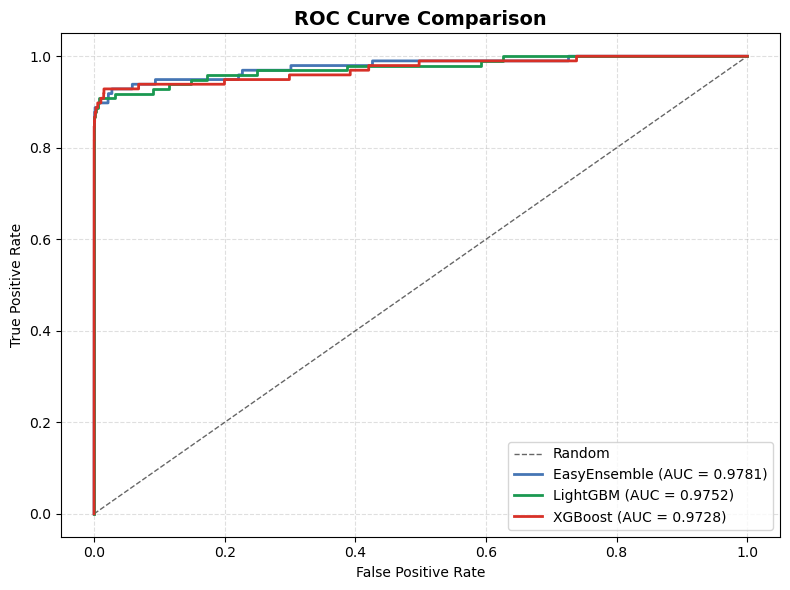

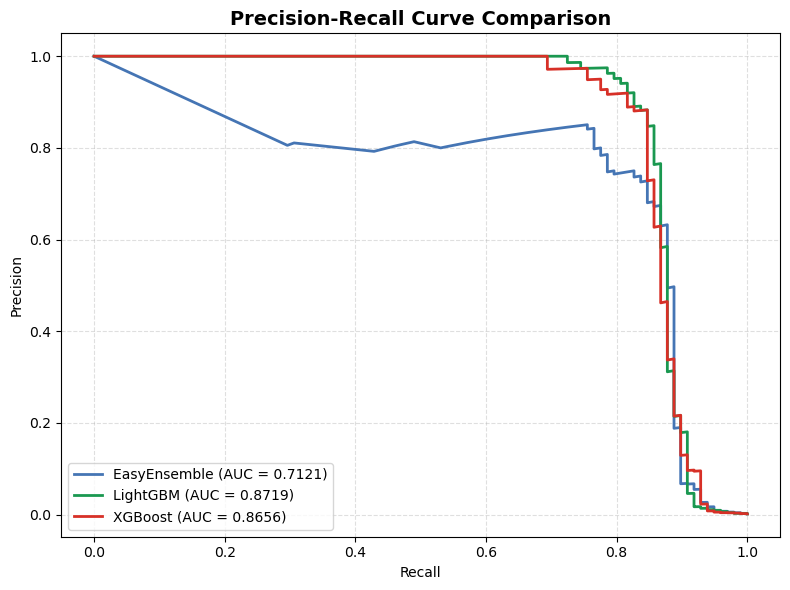

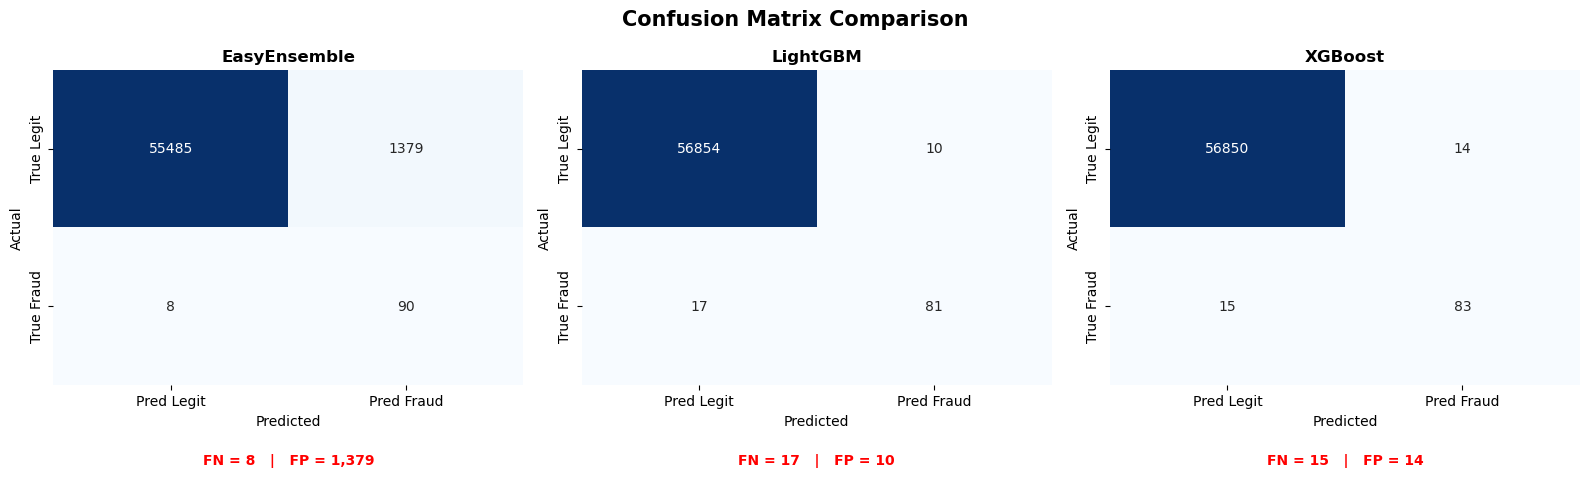

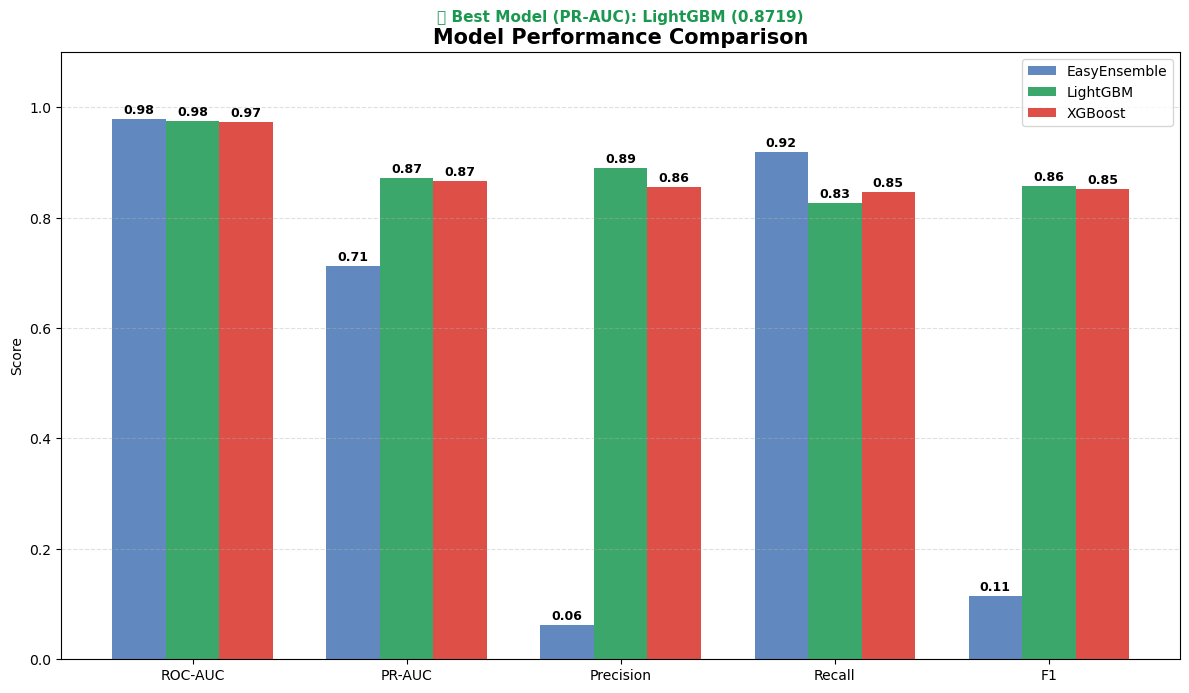

In [28]:

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)


# ─────────────────────────────────────────────────────────────────────────────
# Colors
# ─────────────────────────────────────────────────────────────────────────────
MODEL_COLORS = {
    "EasyEnsemble": "#4575b4",
    "LightGBM": "#1a9850",
    "XGBoost": "#d73027",
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Extract best params (FIXED for EasyEnsemble)
# ══════════════════════════════════════════════════════════════════════════════

# --- EasyEnsemble (special handling) ---
best_row_easy = results_easy.sort_values("mean_test_score", ascending=False).iloc[0]
all_params_easy = best_row_easy["params"]

easy_params = {}
estimator_params = {}

for key, val in all_params_easy.items():
    if key.startswith("estimator__"):
        estimator_params[key.replace("estimator__", "")] = val
    else:
        easy_params[key] = val

print("EasyEnsemble params :", easy_params)
print("Inner estimator params:", estimator_params)

# --- LightGBM & XGBoost ---
best_params_lgbm = results_lightgbm.sort_values("mean_test_score", ascending=False).iloc[0]["params"]
best_params_xgb  = results_xg.sort_values("mean_test_score", ascending=False).iloc[0]["params"]

print("Best LightGBM params :", best_params_lgbm)
print("Best XGBoost params  :", best_params_xgb)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Refit models
# ══════════════════════════════════════════════════════════════════════════════

# EasyEnsemble (correct construction)
inner_estimator = DecisionTreeClassifier(
    class_weight="balanced",
    **estimator_params
)

model_easy = EasyEnsembleClassifier(
    estimator=inner_estimator,
    random_state=42,
    n_jobs=-1,
    **easy_params
)

# Other models
model_lgbm = LGBMClassifier(
    **best_params_lgbm,
    random_state=42,
    n_jobs=-1
)

model_xgb = XGBClassifier(
    **best_params_xgb,
    random_state=42,
    n_jobs=-1,
    eval_metric="aucpr",
    verbosity=0
)

# Fit
model_easy.fit(X_train_scaled, y_train)
model_lgbm.fit(X_train_scaled, y_train)
model_xgb.fit(X_train_scaled, y_train)

print("✅ All models refit successfully")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Predictions & Metrics
# ══════════════════════════════════════════════════════════════════════════════

fitted_models = {
    "EasyEnsemble": model_easy,
    "LightGBM": model_lgbm,
    "XGBoost": model_xgb,
}

metrics = {}

for name, model in fitted_models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, preds)
    cm_norm = confusion_matrix(y_test, preds, normalize="true")

    tn, fp, fn, tp = cm.ravel()

    fpr, tpr, _ = roc_curve(y_test, probs)
    prec, rec, _ = precision_recall_curve(y_test, probs)

    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    precision_v = tp / (tp + fp) if (tp + fp) else 0
    recall_v = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision_v * recall_v / (precision_v + recall_v) if (precision_v + recall_v) else 0

    metrics[name] = dict(
        cm=cm, cm_norm=cm_norm,
        tn=tn, fp=fp, fn=fn, tp=tp,
        fpr=fpr, tpr=tpr, prec=prec, rec=rec,
        roc_auc=roc_auc, pr_auc=pr_auc,
        precision=precision_v, recall=recall_v, f1=f1
    )

names = list(metrics.keys())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — CLEAN SEPARATE PLOTS
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# 1. ROC CURVE (ALL MODELS)
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="Random")

for name, m in metrics.items():
    plt.plot(m["fpr"], m["tpr"],
             color=MODEL_COLORS[name],
             lw=2,
             label=f"{name} (AUC = {m['roc_auc']:.4f})")

plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ROC_Curve_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 2. PRECISION-RECALL CURVE
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

for name, m in metrics.items():
    plt.plot(m["rec"], m["prec"],
             color=MODEL_COLORS[name],
             lw=2,
             label=f"{name} (AUC = {m['pr_auc']:.4f})")

plt.title("Precision-Recall Curve Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Precision-Recall_Curve_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()



# ─────────────────────────────────────────────────────────────────────────────
# 3. CONFUSION MATRICES (SIDE-BY-SIDE)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, m) in zip(axes, metrics.items()):
    sns.heatmap(m["cm"],
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                ax=ax,
                xticklabels=["Pred Legit", "Pred Fraud"],
                yticklabels=["True Legit", "True Fraud"])

    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # add FN / FP info
    ax.text(0.5, -0.25,
            f"FN = {m['fn']:,}   |   FP = {m['fp']:,}",
            transform=ax.transAxes,
            ha="center",
            fontsize=10,
            color="red",
            fontweight="bold")

plt.suptitle("Confusion Matrix Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("Confusion_Matrix_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4. METRIC COMPARISON (BIG CLEAN BAR CHART)
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 7))

metric_names = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1"]
x = np.arange(len(metric_names))
width = 0.25

for i, (name, m) in enumerate(metrics.items()):
    values = [m["roc_auc"], m["pr_auc"], m["precision"], m["recall"], m["f1"]]

    bars = plt.bar(x + i * width, values,
                   width=width,
                   label=name,
                   color=MODEL_COLORS[name],
                   alpha=0.85)

    # value labels
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{val:.2f}",
                 ha="center",
                 fontsize=9,
                 fontweight="bold")

plt.xticks(x + width, metric_names)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

# highlight best model
best_model = max(metrics.items(), key=lambda x: x[1]["pr_auc"])
plt.text(0.5, 1.05,
         f"🏆 Best Model (PR-AUC): {best_model[0]} ({best_model[1]['pr_auc']:.4f})",
         transform=plt.gca().transAxes,
         ha="center",
         fontsize=11,
         fontweight="bold",
         color=MODEL_COLORS[best_model[0]])
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")


plt.tight_layout()
plt.show()

# Selecting Best Model based on Combinations of Parameters

# Selecting LightGBM model for further processing as it was having PR-AUC ( Average_precision) Score of 0.811583 and AUC of 0.8719

In [29]:
from lightgbm import LGBMClassifier
model_lgbm_final = LGBMClassifier(n_estimators=500,learning_rate=0.1,num_leaves=50,
                                  max_depth=-1,min_child_samples=10,subsample=0.6,
                                  colsample_bytree=0.8,class_weight="balanced",verbosity = -1)

model_lgbm_final.fit(X_train_scaled, y_train)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               min_child_samples=10, n_estimators=500, num_leaves=50,
               subsample=0.6, verbosity=-1)